In [1]:
import os

BASE_DATASET_PATH = '/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color'
WORKING_DIR    = '/kaggle/working'
CHECKPOINT_DIR = os.path.join(WORKING_DIR, 'checkpoints')
LOG_DIR        = os.path.join(WORKING_DIR, 'logs')
EXPORT_DIR     = '/kaggle/input/notebooks/adityarajpaul/02-preprocessing/exports'
IMAGE_SIZE        = (300, 300)
IMAGE_SHAPE       = (300, 300, 3)
BATCH_SIZE        = 32
NUM_CLASSES       = 38
RANDOM_SEED       = 42
TRAIN_SPLIT       = 0.8
VAL_SPLIT         = 0.1
TEST_SPLIT        = 0.1
INITIAL_EPOCHS    = 30
LEARNING_RATE     = 1e-3
FINE_TUNE_LR      = 1e-5

for directory in [CHECKPOINT_DIR, LOG_DIR, EXPORT_DIR]:
    os.makedirs(directory, exist_ok=True)

CLASS_NAMES = [
    'Apple___Apple_scab',
    'Apple___Black_rot',
    'Apple___Cedar_apple_rust',
    'Apple___healthy',
    'Blueberry___healthy',
    'Cherry_(including_sour)___Powdery_mildew',
    'Cherry_(including_sour)___healthy',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn_(maize)___Common_rust_',
    'Corn_(maize)___Northern_Leaf_Blight',
    'Corn_(maize)___healthy',
    'Grape___Black_rot',
    'Grape___Esca_(Black_Measles)',
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
    'Grape___healthy',
    'Orange___Haunglongbing_(Citrus_greening)',
    'Peach___Bacterial_spot',
    'Peach___healthy',
    'Pepper,_bell___Bacterial_spot',
    'Pepper,_bell___healthy',
    'Potato___Early_blight',
    'Potato___Late_blight',
    'Potato___healthy',
    'Raspberry___healthy',
    'Soybean___healthy',
    'Squash___Powdery_mildew',
    'Strawberry___Leaf_scorch',
    'Strawberry___healthy',
    'Tomato___Bacterial_spot',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus',
    'Tomato___healthy',
]

print("✓ Config loaded")

✓ Config loaded


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import json
import glob
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"GPU devices        : {tf.config.list_physical_devices('GPU')}")

2026-06-05 22:35:05.323310: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780698905.558819      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780698905.619935      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780698906.156831      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780698906.156880      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780698906.156883      23 computation_placer.cc:177] computation placer alr

TensorFlow version : 2.19.0
GPU available      : True
GPU devices        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# ── This notebook's preprocessing outputs are not available ──
# ── across sessions, so we reload the splits we saved       ──
# ── to /kaggle/working/exports/ in notebook 02             ──

splits_path  = os.path.join(EXPORT_DIR, 'dataset_splits.json')
weights_path = os.path.join(EXPORT_DIR, 'class_weights.json')

# Check files exist before loading
for path in [splits_path, weights_path]:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"\n✗ File not found: {path}"
            f"\n  Run 02_preprocessing.ipynb first and ensure"
            f"\n  files were saved to {EXPORT_DIR}"
        )

# Load splits
with open(splits_path, 'r') as f:
    splits = json.load(f)

paths_train  = np.array(splits['paths_train'])
paths_val    = np.array(splits['paths_val'])
paths_test   = np.array(splits['paths_test'])
labels_train = np.array(splits['labels_train'])
labels_val   = np.array(splits['labels_val'])
labels_test  = np.array(splits['labels_test'])

# Load class weights
with open(weights_path, 'r') as f:
    raw_weights = json.load(f)

# JSON keys are strings — convert back to integers
class_weight_dict = {int(k): v for k, v in raw_weights.items()}

print(f"✓ Splits loaded")
print(f"  Train  : {len(paths_train):,} images")
print(f"  Val    : {len(paths_val):,} images")
print(f"  Test   : {len(paths_test):,} images")
print(f"\n✓ Class weights loaded ({len(class_weight_dict)} classes)")
print(f"  Highest weight : {max(class_weight_dict.values()):.4f}")
print(f"  Lowest weight  : {min(class_weight_dict.values()):.4f}")

✓ Splits loaded
  Train  : 43,443 images
  Val    : 5,431 images
  Test   : 5,431 images

✓ Class weights loaded (38 classes)
  Highest weight : 9.3708
  Lowest weight  : 0.2595


In [4]:
AUTOTUNE = tf.data.AUTOTUNE

augmentation_layer = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomBrightness(0.15, value_range=(0, 255)),
    tf.keras.layers.RandomContrast(0.15),
], name="augmentation")

def load_and_preprocess(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

def load_and_augment(path, label):
    image, label = load_and_preprocess(path, label)
    image = augmentation_layer(image, training=True)
    return image, label

train_dataset = (
    tf.data.Dataset.from_tensor_slices((paths_train, labels_train))
    .shuffle(buffer_size=len(paths_train), seed=RANDOM_SEED)
    .map(load_and_augment, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((paths_val, labels_val))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices((paths_test, labels_test))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print(f"✓ tf.data pipelines rebuilt")
print(f"  Training batches   : {len(train_dataset)}")
print(f"  Validation batches : {len(val_dataset)}")
print(f"  Test batches       : {len(test_dataset)}")

I0000 00:00:1780698920.493301      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780698920.496209      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


✓ tf.data pipelines rebuilt
  Training batches   : 1358
  Validation batches : 170
  Test batches       : 170


In [5]:
def build_model():
    # ── Base model: EfficientNetB3 pretrained on ImageNet ────
    base_model = tf.keras.applications.EfficientNetB3(
        include_top=False,
        weights='imagenet',
        input_shape=IMAGE_SHAPE,
    )
    base_model.trainable = False

    print(f"Base model layers  : {len(base_model.layers)}")
    print(f"Trainable params   : {sum([tf.size(w).numpy() for w in base_model.trainable_weights]):,}")
    print(f"Base frozen        : {not base_model.trainable}")

    # ── Custom classification head ───────────────────────────
    inputs = tf.keras.Input(shape=IMAGE_SHAPE, name="input_image")

    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(x)
    x = tf.keras.layers.BatchNormalization(name="bn_head")(x)
    x = tf.keras.layers.Dense(256, activation='relu', name="dense_256")(x)
    x = tf.keras.layers.Dropout(0.3, name="dropout")(x)
    outputs = tf.keras.layers.Dense(
        NUM_CLASSES,
        activation='softmax',
        name="predictions"
    )(x)

    model = tf.keras.Model(inputs, outputs, name="crop_disease_classifier")
    return model, base_model

print("Building model...")
model, base_model = build_model()

# ── Count parameters ─────────────────────────────────────────
total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
frozen_params    = total_params - trainable_params

print(f"\n{'='*45}")
print(f"MODEL SUMMARY")
print(f"{'='*45}")
print(f"Total parameters    : {total_params:,}")
print(f"Trainable (head)    : {trainable_params:,}")
print(f"Frozen (base)       : {frozen_params:,}")
print(f"{'='*45}")
print(f"\nOnly {trainable_params/total_params*100:.1f}% of parameters")
print(f"will be updated during initial training")

Building model...
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model layers  : 385
Trainable params   : 0
Base frozen        : True

MODEL SUMMARY
Total parameters    : 11,192,917
Trainable (head)    : 406,310
Frozen (base)       : 10,786,607

Only 3.6% of parameters
will be updated during initial training


In [6]:
def get_latest_checkpoint():
    checkpoints = glob.glob(os.path.join(CHECKPOINT_DIR, 'initial_*.h5'))
    if not checkpoints:
        return None
    return max(checkpoints, key=os.path.getmtime)

def get_initial_epoch():
    log_path = os.path.join(CHECKPOINT_DIR, 'initial_training_log.csv')
    if not os.path.exists(log_path):
        return 0
    with open(log_path, 'r') as f:
        lines = f.readlines()
    completed = len(lines) - 1
    return max(0, completed)

# ── Check for existing checkpoint ────────────────────────────
latest_checkpoint = get_latest_checkpoint()
initial_epoch     = get_initial_epoch()

if latest_checkpoint:
    print(f"✓ Checkpoint found: {os.path.basename(latest_checkpoint)}")
    print(f"  Resuming from epoch {initial_epoch + 1}")
    print(f"  Loading model weights...")
    model.load_weights(latest_checkpoint)
    print(f"  Weights loaded successfully")
else:
    print(f"No checkpoint found")
    print(f"Training will start fresh from epoch 1")

print(f"\nInitial epoch set to: {initial_epoch}")

No checkpoint found
Training will start fresh from epoch 1

Initial epoch set to: 0


In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3_accuracy')
    ]
)

print("✓ Model compiled")
print(f"\nOptimizer  : Adam (lr={LEARNING_RATE})")
print(f"Loss       : SparseCategoricalCrossentropy")
print(f"Metrics    : accuracy, top3_accuracy")
print(f"\nNote: SparseCategoricalCrossentropy expects integer labels")
print(f"      not one-hot encoded vectors — matches our label format")

✓ Model compiled

Optimizer  : Adam (lr=0.001)
Loss       : SparseCategoricalCrossentropy
Metrics    : accuracy, top3_accuracy

Note: SparseCategoricalCrossentropy expects integer labels
      not one-hot encoded vectors — matches our label format


In [8]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(
            CHECKPOINT_DIR,
            'initial_epoch_{epoch:02d}_valacc_{val_accuracy:.4f}.h5'
        ),
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        os.path.join(CHECKPOINT_DIR, 'initial_training_log.csv'),
        append=True
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print("✓ Callbacks defined")
print(f"\n  ModelCheckpoint  → saves to {CHECKPOINT_DIR}")
print(f"  CSVLogger        → appends to initial_training_log.csv")
print(f"  EarlyStopping    → patience=7 epochs on val_loss")
print(f"  ReduceLROnPlateau→ halves LR after 3 stagnant epochs")

✓ Callbacks defined

  ModelCheckpoint  → saves to /kaggle/working/checkpoints
  CSVLogger        → appends to initial_training_log.csv
  EarlyStopping    → patience=7 epochs on val_loss
  ReduceLROnPlateau→ halves LR after 3 stagnant epochs


In [9]:
print("="*55)
print("STARTING INITIAL TRAINING (FROZEN BASE)")
print("="*55)
print(f"Starting from epoch  : {initial_epoch + 1}")
print(f"Max epochs           : {INITIAL_EPOCHS}")
print(f"Batch size           : {BATCH_SIZE}")
print(f"Training samples     : {len(paths_train):,}")
print(f"Steps per epoch      : {len(train_dataset)}")
print("="*55)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=INITIAL_EPOCHS,
    initial_epoch=initial_epoch,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print("\n✓ Training complete")
print(f"  Final val_accuracy  : {max(history.history['val_accuracy']):.4f}")
print(f"  Final val_loss      : {min(history.history['val_loss']):.4f}")

STARTING INITIAL TRAINING (FROZEN BASE)
Starting from epoch  : 1
Max epochs           : 30
Batch size           : 32
Training samples     : 43,443
Steps per epoch      : 1358
Epoch 1/30


I0000 00:00:1780698942.038454      71 service.cc:152] XLA service 0x7ac32c003960 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780698942.038493      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780698942.038498      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780698946.795995      71 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-05 22:35:58.917160: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 22:35:59.075082: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 22:35:59.528997: E external/local_xl

1357/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.7076 - loss: 1.0890 - top3_accuracy: 0.8646

2026-06-05 22:45:20.514520: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 22:45:20.662280: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 22:45:21.044194: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 22:45:21.192912: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 22:45:21.995606: E external/local_xla/xla/stream_

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.7077 - loss: 1.0887 - top3_accuracy: 0.8646

...


Epoch 17: finished saving model to /kaggle/working/checkpoints/initial_epoch_17_valacc_0.9709.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 523s 385ms/step - accuracy: 0.9489 - loss: 0.1686 - top3_accuracy: 0.9945 - val_accuracy: 0.9709 - val_loss: 0.0932 - val_top3_accuracy: 0.9978 - learning_rate: 5.0000e-04
Epoch 18/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.9520 - loss: 0.1565 - top3_accuracy: 0.9959
Epoch 18: val_accuracy improved from 0.97091 to 0.97441, saving model to /kaggle/working/checkpoints/initial_epoch_18_valacc_0.9744.h5



Epoch 18: finished saving model to /kaggle/working/checkpoints/initial_epoch_18_valacc_0.9744.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 521s 383ms/step - accuracy: 0.9504 - loss: 0.1592 - top3_accuracy: 0.9954 - val_accuracy: 0.9744 - val_loss: 0.0902 - val_top3_accuracy: 0.9982 - learning_rate: 5.0000e-04
Epoch 19/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.9524 - loss: 0.1595 - top3_accuracy: 0.9948
Epoch 19: val_accuracy did not improve from 0.97441
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 521s 384ms/step - accuracy: 0.9529 - loss: 0.1549 - top3_accuracy: 0.9948 - val_accuracy: 0.9742 - val_loss: 0.0877 - val_top3_accuracy: 0.9982 - learning_rate: 5.0000e-04
Epoch 20/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.9528 - loss: 0.1449 - top3_accuracy: 0.9956
Epoch 20: val_accuracy did not improve from 0.97441
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 520s 383ms/step - accuracy: 0.9520 - loss: 0.1478 - top3_accuracy: 0.9954 - val_accuracy: 0.9696 - val_loss: 0.0954 - val_top3_accu


Epoch 25: finished saving model to /kaggle/working/checkpoints/initial_epoch_25_valacc_0.9753.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 520s 383ms/step - accuracy: 0.9578 - loss: 0.1322 - top3_accuracy: 0.9964 - val_accuracy: 0.9753 - val_loss: 0.0760 - val_top3_accuracy: 0.9983 - learning_rate: 5.0000e-04
Epoch 26/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.9568 - loss: 0.1307 - top3_accuracy: 0.9958
Epoch 26: val_accuracy did not improve from 0.97533
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 518s 381ms/step - accuracy: 0.9550 - loss: 0.1392 - top3_accuracy: 0.9959 - val_accuracy: 0.9753 - val_loss: 0.0806 - val_top3_accuracy: 0.9982 - learning_rate: 5.0000e-04
Epoch 27/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.9595 - loss: 0.1239 - top3_accuracy: 0.9969
Epoch 27: val_accuracy improved from 0.97533 to 0.97606, saving model to /kaggle/working/checkpoints/initial_epoch_27_valacc_0.9761.h5



Epoch 27: finished saving model to /kaggle/working/checkpoints/initial_epoch_27_valacc_0.9761.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 527s 388ms/step - accuracy: 0.9586 - loss: 0.1298 - top3_accuracy: 0.9962 - val_accuracy: 0.9761 - val_loss: 0.0785 - val_top3_accuracy: 0.9980 - learning_rate: 5.0000e-04
Epoch 28/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.9572 - loss: 0.1360 - top3_accuracy: 0.9959
Epoch 28: val_accuracy did not improve from 0.97606

Epoch 28: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 524s 386ms/step - accuracy: 0.9572 - loss: 0.1344 - top3_accuracy: 0.9961 - val_accuracy: 0.9705 - val_loss: 0.0910 - val_top3_accuracy: 0.9980 - learning_rate: 5.0000e-04
Epoch 29/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.9606 - loss: 0.1215 - top3_accuracy: 0.9968
Epoch 29: val_accuracy improved from 0.97606 to 0.97956, saving model to /kaggle/working/checkpoints/initial_epoch_29_valacc_0.9796.h5



Epoch 29: finished saving model to /kaggle/working/checkpoints/initial_epoch_29_valacc_0.9796.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 524s 386ms/step - accuracy: 0.9615 - loss: 0.1166 - top3_accuracy: 0.9967 - val_accuracy: 0.9796 - val_loss: 0.0716 - val_top3_accuracy: 0.9980 - learning_rate: 2.5000e-04
Epoch 30/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.9637 - loss: 0.1043 - top3_accuracy: 0.9974
Epoch 30: val_accuracy did not improve from 0.97956
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 525s 386ms/step - accuracy: 0.9644 - loss: 0.1047 - top3_accuracy: 0.9974 - val_accuracy: 0.9761 - val_loss: 0.0764 - val_top3_accuracy: 0.9983 - learning_rate: 2.5000e-04
Restoring model weights from the end of the best epoch: 29.

✓ Training complete
  Final val_accuracy  : 0.9796
  Final val_loss      : 0.0716


Plotting 30 epochs from CSV log


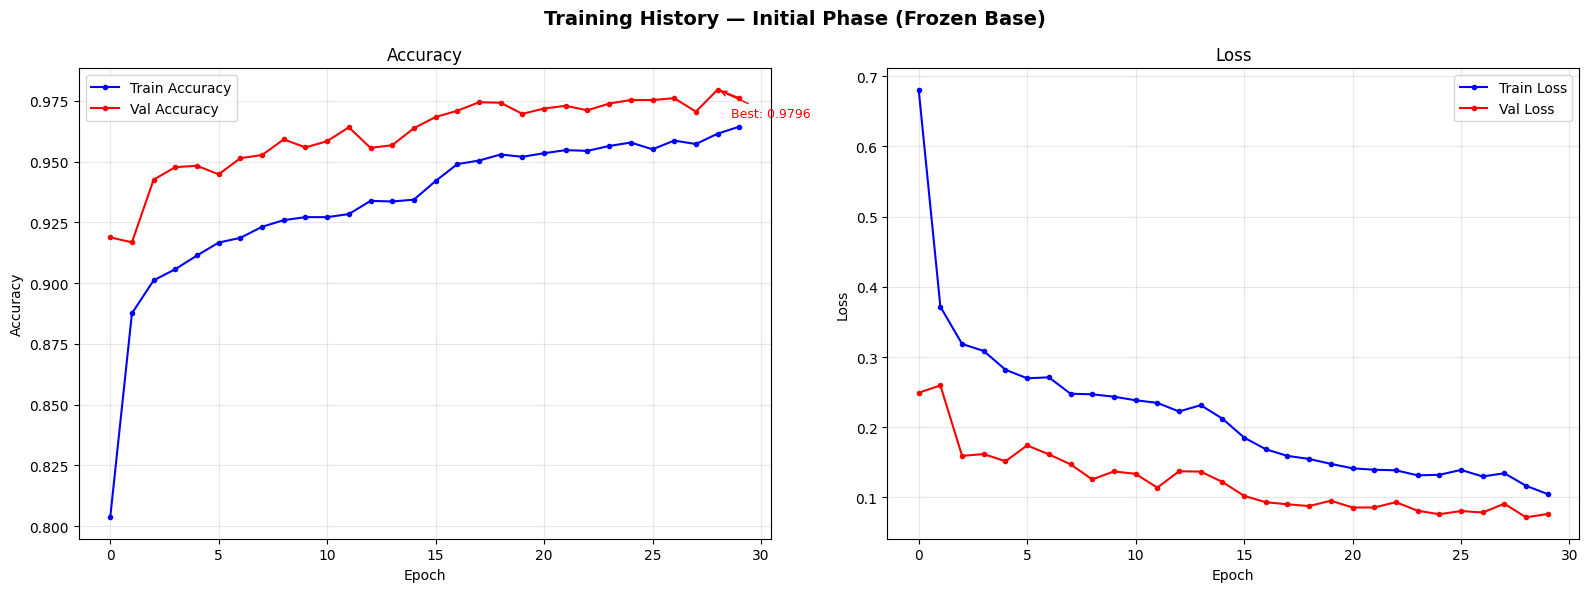

✓ Plot saved to logs/


In [10]:
def plot_training_history(history):
    # ── Load full history from CSV in case of resumed session ──
    log_path = os.path.join(CHECKPOINT_DIR, 'initial_training_log.csv')

    if os.path.exists(log_path):
        df = pd.read_csv(log_path)
        epochs       = df['epoch'].tolist()
        acc          = df['accuracy'].tolist()
        val_acc      = df['val_accuracy'].tolist()
        loss         = df['loss'].tolist()
        val_loss     = df['val_loss'].tolist()
        print(f"Plotting {len(epochs)} epochs from CSV log")
    else:
        epochs   = range(len(history.history['accuracy']))
        acc      = history.history['accuracy']
        val_acc  = history.history['val_accuracy']
        loss     = history.history['loss']
        val_loss = history.history['val_loss']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Training History — Initial Phase (Frozen Base)',
                 fontsize=14, fontweight='bold')

    # Accuracy plot
    axes[0].plot(epochs, acc,     'b-o', markersize=3, label='Train Accuracy')
    axes[0].plot(epochs, val_acc, 'r-o', markersize=3, label='Val Accuracy')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].annotate(
        f'Best: {max(val_acc):.4f}',
        xy=(val_acc.index(max(val_acc)), max(val_acc)),
        xytext=(10, -20), textcoords='offset points',
        arrowprops=dict(arrowstyle='->', color='red'),
        color='red', fontsize=9
    )

    # Loss plot
    axes[1].plot(epochs, loss,     'b-o', markersize=3, label='Train Loss')
    axes[1].plot(epochs, val_loss, 'r-o', markersize=3, label='Val Loss')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(LOG_DIR, 'initial_training_history.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Plot saved to logs/")

plot_training_history(history)

In [11]:
# ── Load full log for summary ─────────────────────────────────
log_path = os.path.join(CHECKPOINT_DIR, 'initial_training_log.csv')
df       = pd.read_csv(log_path)

best_epoch   = df.loc[df['val_accuracy'].idxmax()]
final_epoch  = df.iloc[-1]

print("="*55)
print("INITIAL TRAINING SUMMARY")
print("="*55)
print(f"Total epochs trained : {len(df)}")
print(f"\nBest epoch           : {int(best_epoch['epoch']) + 1}")
print(f"  val_accuracy       : {best_epoch['val_accuracy']:.4f}")
print(f"  val_loss           : {best_epoch['val_loss']:.4f}")
print(f"  top3_accuracy      : {best_epoch.get('val_top3_accuracy', 'N/A')}")
print(f"\nFinal epoch          : {int(final_epoch['epoch']) + 1}")
print(f"  val_accuracy       : {final_epoch['val_accuracy']:.4f}")
print(f"  val_loss           : {final_epoch['val_loss']:.4f}")

# ── List saved checkpoints ────────────────────────────────────
checkpoints = glob.glob(os.path.join(CHECKPOINT_DIR, 'initial_*.h5'))
print(f"\nCheckpoints saved    : {len(checkpoints)}")
for cp in sorted(checkpoints):
    size = os.path.getsize(cp) / (1024*1024)
    print(f"  {os.path.basename(cp)} ({size:.1f} MB)")

print(f"\n{'='*55}")
if best_epoch['val_accuracy'] >= 0.90:
    print(f"✓ Target accuracy achieved (≥90%)")
    print(f"  Proceed to 04_fine_tuning.ipynb")
elif best_epoch['val_accuracy'] >= 0.85:
    print(f"△ Acceptable accuracy — fine tuning recommended")
    print(f"  Proceed to 04_fine_tuning.ipynb")
else:
    print(f"✗ Accuracy below target — review training before proceeding")
    print(f"  Check class weights and augmentation settings")
print(f"{'='*55}")

INITIAL TRAINING SUMMARY
Total epochs trained : 30

Best epoch           : 29
  val_accuracy       : 0.9796
  val_loss           : 0.0716
  top3_accuracy      : 0.9979745745658876

Final epoch          : 30
  val_accuracy       : 0.9761
  val_loss           : 0.0764

Checkpoints saved    : 14
  initial_epoch_01_valacc_0.9188.h5 (46.5 MB)
  initial_epoch_03_valacc_0.9426.h5 (46.5 MB)
  initial_epoch_04_valacc_0.9477.h5 (46.5 MB)
  initial_epoch_05_valacc_0.9483.h5 (46.5 MB)
  initial_epoch_07_valacc_0.9514.h5 (46.5 MB)
  initial_epoch_08_valacc_0.9527.h5 (46.5 MB)
  initial_epoch_09_valacc_0.9591.h5 (46.5 MB)
  initial_epoch_12_valacc_0.9641.h5 (46.5 MB)
  initial_epoch_16_valacc_0.9683.h5 (46.5 MB)
  initial_epoch_17_valacc_0.9709.h5 (46.5 MB)
  initial_epoch_18_valacc_0.9744.h5 (46.5 MB)
  initial_epoch_25_valacc_0.9753.h5 (46.5 MB)
  initial_epoch_27_valacc_0.9761.h5 (46.5 MB)
  initial_epoch_29_valacc_0.9796.h5 (46.5 MB)

✓ Target accuracy achieved (≥90%)
  Proceed to 04_fine_tuning

In [12]:
import glob
import os
import re

# 1. Grab all saved checkpoints
all_checkpoints = glob.glob(os.path.join(CHECKPOINT_DIR, 'initial_*.h5'))

if not all_checkpoints:
    print("⚠️ No checkpoints found in the directory.")
else:
    # 2. Fixed regex: [0-9]+\.[0-9]+ ensures it only grabs a proper decimal number
    # (e.g., '0.9720' instead of '0.9720.')
    def get_val_accuracy(filename):
        match = re.search(r'valacc_([0-9]+\.[0-9]+)', filename)
        return float(match.group(1)) if match else 0.0

    # Sort checkpoints by accuracy in ascending order
    all_checkpoints.sort(key=get_val_accuracy)
    best = all_checkpoints[-1]

    deleted = 0
    best_abs = os.path.abspath(best)
    
    for cp in all_checkpoints:
        cp_abs = os.path.abspath(cp)
        if cp_abs != best_abs:
            try:
                os.remove(cp_abs)
                deleted += 1
            except Exception as e:
                print(f"Could not delete {os.path.basename(cp_abs)}: {e}")

    print(f"✓ Deleted {deleted} old checkpoints")
    
    if os.path.exists(best_abs):
        print(f"✓ Kept Best Checkpoint: {os.path.basename(best_abs)}")
        print(f"  Size: {os.path.getsize(best_abs)/(1024*1024):.1f} MB")
    else:
        print("❌ Error: The best checkpoint file could not be found on disk.")

✓ Deleted 13 old checkpoints
✓ Kept Best Checkpoint: initial_epoch_29_valacc_0.9796.h5
  Size: 46.5 MB
